# Notebook 04 — Evaluate RoBERTa on Original Test Set

**Project:** MSc AI Dissertation — AI-Generated Text Detection  
**Student:** Abdul Hannaan Mohammed | B00409227 | UWS  
**Week:** 3 of 13  

**Goal of this notebook:**
- Load the fine-tuned RoBERTa model from `models/checkpoints/roberta-hc3-best/`
- Run inference on the held-out test set (`data/processed/test.csv`)
- Compute Accuracy, Precision, Recall, F1-Score
- Plot and save Confusion Matrix heatmap
- Plot and save ROC Curve
- Plot and save Precision-Recall Curve
- Save all results tables for the dissertation

> **DISSERTATION NOTE:** All outputs from this notebook go into **Chapter 5 — Results and Evaluation**

## 1. Imports and Paths

In [2]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    classification_report
)

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR    = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT    = os.path.dirname(NOTEBOOK_DIR)
DATA_PROCESSED  = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODELS_DIR      = os.path.join(PROJECT_ROOT, 'models', 'checkpoints')
RESULTS_FIGS    = os.path.join(PROJECT_ROOT, 'results', 'figures')
RESULTS_METRICS = os.path.join(PROJECT_ROOT, 'results', 'metrics')
RESULTS_TABLES  = os.path.join(PROJECT_ROOT, 'results', 'tables')
RESULTS_CM      = os.path.join(PROJECT_ROOT, 'results', 'confusion_matrices')

for path in [RESULTS_FIGS, RESULTS_METRICS, RESULTS_TABLES, RESULTS_CM]:
    os.makedirs(path, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'Project root: {PROJECT_ROOT}')

Device : cuda
GPU    : NVIDIA GeForce RTX 3060 Laptop GPU
Project root: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection


## 2. Load the Fine-Tuned Model and Tokeniser

In [3]:
BEST_MODEL_DIR = os.path.join(MODELS_DIR, 'roberta-hc3-best')

print(f'Loading model from: {BEST_MODEL_DIR}')

# Load tokeniser and model from the saved checkpoint
tokeniser = RobertaTokenizerFast.from_pretrained(BEST_MODEL_DIR)
model     = RobertaForSequenceClassification.from_pretrained(BEST_MODEL_DIR)

# Move model to GPU if available
model = model.to(DEVICE)

# Set to evaluation mode — disables dropout layers
model.eval()

print('Model and tokeniser loaded successfully.')
print(f'Model is on: {next(model.parameters()).device}')

Loading model from: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\models\checkpoints\roberta-hc3-best
Model and tokeniser loaded successfully.
Model is on: cuda:0


## 3. Load the Test Set

In [4]:
test_df = pd.read_csv(os.path.join(DATA_PROCESSED, 'test.csv'))

print(f'Test samples : {len(test_df):,}')
print(f'Human (0)    : {(test_df["label"]==0).sum():,}')
print(f'AI (1)       : {(test_df["label"]==1).sum():,}')
test_df.head(3)

Test samples : 11,820
Human (0)    : 7,888
AI (1)       : 3,932


,text,label,label_name,source,word_count
0,I would guess - I 'm not entirely sure - that ...,0,human,reddit_eli5,160
1,I read a while ago on reddit that it was just ...,0,human,reddit_eli5,59
2,Cooperation and tools . A Code Management or C...,0,human,reddit_eli5,118


## 4. Run Inference on the Test Set

We process the test set in batches and collect:
- `predictions` — the predicted class (0 or 1)
- `probabilities` — the softmax probability of class 1 (AI), used for ROC curve

In [5]:
MAX_LENGTH  = 512
BATCH_SIZE  = 16   # larger batch is fine during inference — no gradient storage needed

class InferenceDataset(Dataset):
    """Simple dataset for inference — no labels needed."""
    def __init__(self, texts, tokeniser, max_length):
        self.encodings = tokeniser(
            texts,
            max_length=max_length,
            padding='max_length',
            truncation=True
        )

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        return {
            'input_ids':      torch.tensor(self.encodings['input_ids'][idx],      dtype=torch.long),
            'attention_mask': torch.tensor(self.encodings['attention_mask'][idx], dtype=torch.long)
        }


print('Tokenising test set...')
test_dataset = InferenceDataset(test_df['text'].tolist(), tokeniser, MAX_LENGTH)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

all_preds  = []
all_probs  = []   # probability of class 1 (AI) — for ROC/PR curves

print(f'Running inference on {len(test_df):,} test samples...')

with torch.no_grad():   # disable gradient computation during inference
    for batch_idx, batch in enumerate(test_loader):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits

        # Softmax to get class probabilities
        probs = torch.softmax(logits, dim=-1)

        # Predicted class = argmax of logits
        preds = torch.argmax(logits, dim=-1)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs[:, 1].cpu().numpy().tolist())  # prob of class 1 (AI)

        if (batch_idx + 1) % 20 == 0:
            print(f'  Batch {batch_idx+1}/{len(test_loader)} done')

print(f'Inference complete. Total predictions: {len(all_preds):,}')

# Store predictions back in the DataFrame
test_df['predicted_label'] = all_preds
test_df['ai_probability']  = all_probs

Tokenising test set...
Running inference on 11,820 test samples...
  Batch 20/739 done
  Batch 40/739 done
  Batch 60/739 done
  Batch 80/739 done
  Batch 100/739 done
  Batch 120/739 done
  Batch 140/739 done
  Batch 160/739 done
  Batch 180/739 done
  Batch 200/739 done
  Batch 220/739 done
  Batch 240/739 done
  Batch 260/739 done
  Batch 280/739 done
  Batch 300/739 done
  Batch 320/739 done
  Batch 340/739 done
  Batch 360/739 done
  Batch 380/739 done
  Batch 400/739 done
  Batch 420/739 done
  Batch 440/739 done
  Batch 460/739 done
  Batch 480/739 done
  Batch 500/739 done
  Batch 520/739 done
  Batch 540/739 done
  Batch 560/739 done
  Batch 580/739 done
  Batch 600/739 done
  Batch 620/739 done
  Batch 640/739 done
  Batch 660/739 done
  Batch 680/739 done
  Batch 700/739 done
  Batch 720/739 done
Inference complete. Total predictions: 11,820


## 5. Compute Evaluation Metrics

> **DISSERTATION NOTE:** These numbers are the **core results** for Chapter 5.  
> They go into **Table 4 — Classifier Performance on Original Test Set**.
>
> **SCREENSHOT REMINDER:** Screenshot the output of this cell.  
> Save as: `screenshots/09_original_test_results.png`

In [6]:
true_labels = test_df['label'].tolist()
pred_labels = test_df['predicted_label'].tolist()

# Core metrics
accuracy  = accuracy_score(true_labels, pred_labels)
precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels, pred_labels, average='binary', pos_label=1
)

# Confusion matrix values
cm = confusion_matrix(true_labels, pred_labels)
tn, fp, fn, tp = cm.ravel()

print('=' * 55)
print('  RESULTS ON ORIGINAL TEST SET (Table 4)')
print('=' * 55)
print(f'  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision : {precision:.4f}  ({precision*100:.2f}%)')
print(f'  Recall    : {recall:.4f}  ({recall*100:.2f}%)')
print(f'  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)')
print('=' * 55)
print(f'\n  Confusion Matrix:')
print(f'    True Negatives  (Human → Human) : {tn:,}')
print(f'    False Positives (Human → AI)    : {fp:,}')
print(f'    False Negatives (AI → Human)    : {fn:,}')
print(f'    True Positives  (AI → AI)       : {tp:,}')

print('\n--- Full Classification Report ---')
print(classification_report(true_labels, pred_labels,
                            target_names=['Human (0)', 'AI (1)']))

  RESULTS ON ORIGINAL TEST SET (Table 4)
  Accuracy  : 0.9942  (99.42%)
  Precision : 0.9832  (98.32%)
  Recall    : 0.9995  (99.95%)
  F1-Score  : 0.9913  (99.13%)

  Confusion Matrix:
    True Negatives  (Human → Human) : 7,821
    False Positives (Human → AI)    : 67
    False Negatives (AI → Human)    : 2
    True Positives  (AI → AI)       : 3,930

--- Full Classification Report ---
              precision    recall  f1-score   support

   Human (0)       1.00      0.99      1.00      7888
      AI (1)       0.98      1.00      0.99      3932

    accuracy                           0.99     11820
   macro avg       0.99      1.00      0.99     11820
weighted avg       0.99      0.99      0.99     11820



## 6. Confusion Matrix Heatmap

> **DISSERTATION NOTE:** This is **Figure 6** in Chapter 5 (Results and Evaluation).

Confusion matrix figure saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig06_confusion_matrix_original.png


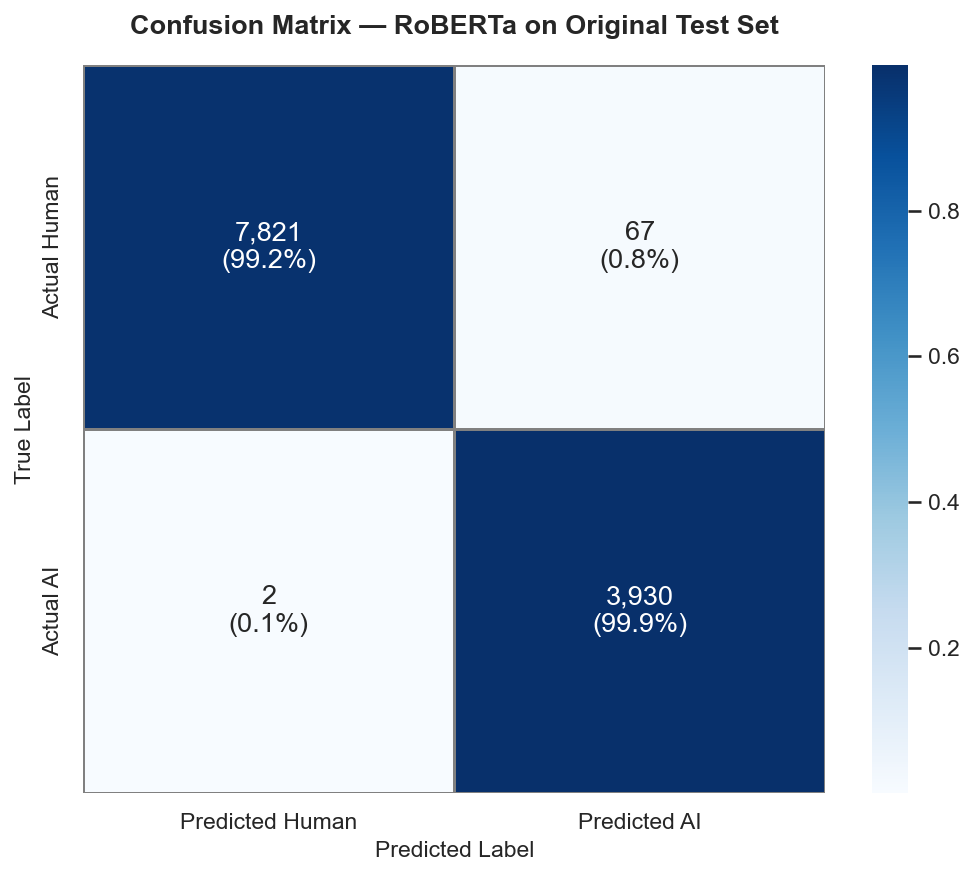

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))

# Normalised confusion matrix (shows percentages)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Build annotation labels showing both count and percentage
annot = np.array([
    [f'{cm[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)' for j in range(2)]
    for i in range(2)
])

sns.heatmap(
    cm_norm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=['Predicted Human', 'Predicted AI'],
    yticklabels=['Actual Human', 'Actual AI'],
    ax=ax,
    linewidths=0.5,
    linecolor='gray',
    annot_kws={'size': 13}
)

ax.set_title('Confusion Matrix — RoBERTa on Original Test Set',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()

cm_fig_path = os.path.join(RESULTS_FIGS, 'fig06_confusion_matrix_original.png')
plt.savefig(cm_fig_path, bbox_inches='tight', dpi=150)

# Also save the raw CM values
cm_csv_path = os.path.join(RESULTS_CM, 'cm_original_test.csv')
pd.DataFrame(cm, index=['Actual Human', 'Actual AI'],
             columns=['Pred Human', 'Pred AI']).to_csv(cm_csv_path)

print(f'Confusion matrix figure saved: {cm_fig_path}')
plt.show()

## 7. ROC Curve

> **DISSERTATION NOTE:** This is **Figure 7** in Chapter 5 (Results and Evaluation).

ROC curve saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig07_roc_curve_original.png
AUC = 0.9999


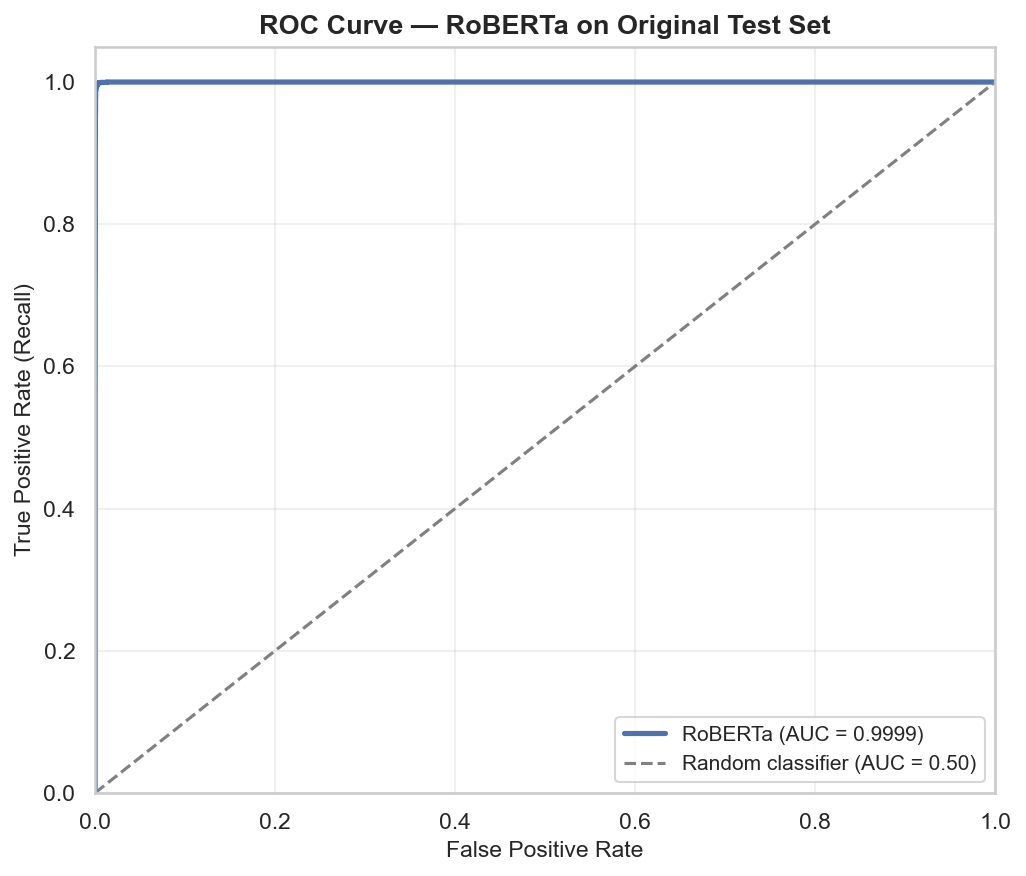

In [8]:
fpr, tpr, thresholds = roc_curve(true_labels, all_probs)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color='#4C72B0', linewidth=2.5,
        label=f'RoBERTa (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linewidth=1.5,
        linestyle='--', label='Random classifier (AUC = 0.50)')

ax.set_title('ROC Curve — RoBERTa on Original Test Set',
             fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(True, alpha=0.3)

plt.tight_layout()

roc_path = os.path.join(RESULTS_FIGS, 'fig07_roc_curve_original.png')
plt.savefig(roc_path, bbox_inches='tight', dpi=150)
print(f'ROC curve saved: {roc_path}')
print(f'AUC = {roc_auc:.4f}')
plt.show()

## 8. Precision-Recall Curve

> **DISSERTATION NOTE:** This is **Figure 8** in Chapter 5 (Results and Evaluation).

PR curve saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig08_pr_curve_original.png
PR AUC = 0.9997


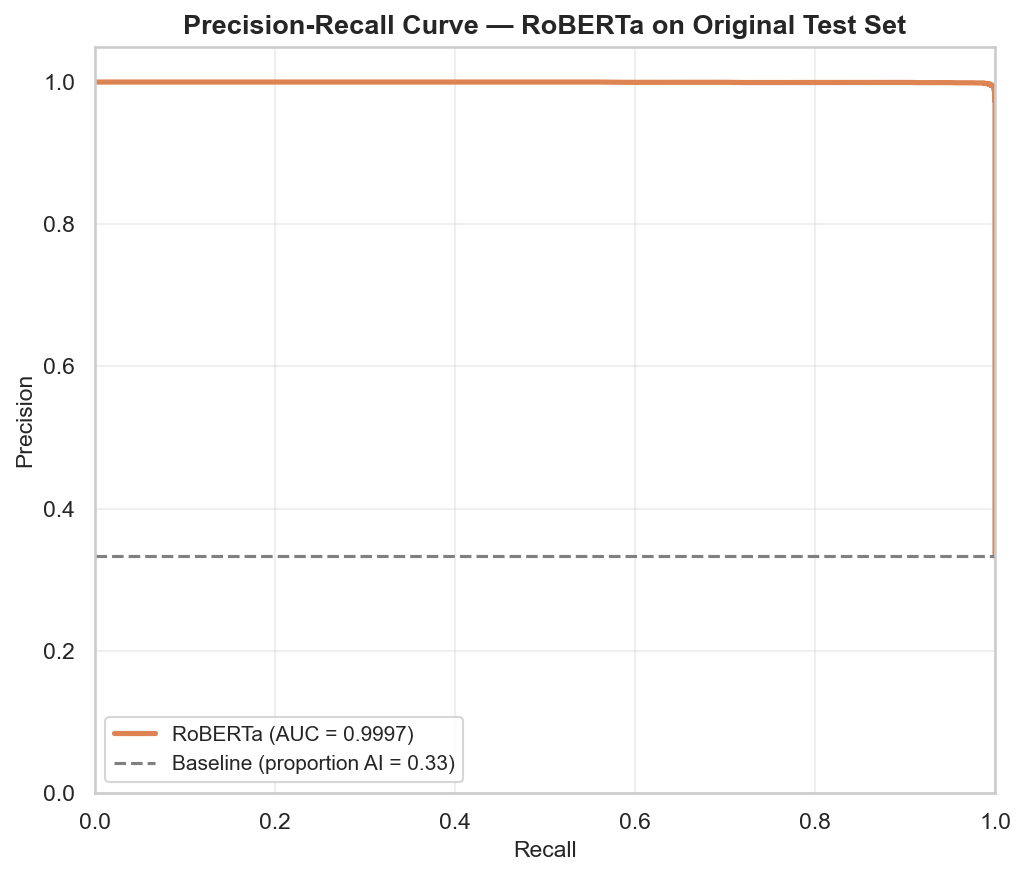

In [9]:
pr_precision, pr_recall, pr_thresholds = precision_recall_curve(true_labels, all_probs)
pr_auc = auc(pr_recall, pr_precision)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(pr_recall, pr_precision, color='#DD8452', linewidth=2.5,
        label=f'RoBERTa (AUC = {pr_auc:.4f})')

# Baseline = proportion of positive class
baseline = (test_df['label'] == 1).mean()
ax.axhline(y=baseline, color='gray', linewidth=1.5, linestyle='--',
           label=f'Baseline (proportion AI = {baseline:.2f})')

ax.set_title('Precision-Recall Curve — RoBERTa on Original Test Set',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.legend(fontsize=10, loc='lower left')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(True, alpha=0.3)

plt.tight_layout()

pr_path = os.path.join(RESULTS_FIGS, 'fig08_pr_curve_original.png')
plt.savefig(pr_path, bbox_inches='tight', dpi=150)
print(f'PR curve saved: {pr_path}')
print(f'PR AUC = {pr_auc:.4f}')
plt.show()

## 9. Save All Results

In [10]:
# ── Save full results JSON ────────────────────────────────────────────────────
original_results = {
    'condition':  'original',
    'n_samples':  len(test_df),
    'accuracy':   round(accuracy,  4),
    'precision':  round(precision, 4),
    'recall':     round(recall,    4),
    'f1':         round(f1,        4),
    'roc_auc':    round(roc_auc,   4),
    'pr_auc':     round(pr_auc,    4),
    'confusion_matrix': {
        'tn': int(tn), 'fp': int(fp),
        'fn': int(fn), 'tp': int(tp)
    }
}

results_json_path = os.path.join(RESULTS_METRICS, 'results_original_test.json')
with open(results_json_path, 'w') as f:
    json.dump(original_results, f, indent=2)

# ── Save results table CSV (for dissertation) ─────────────────────────────────
results_table = pd.DataFrame([{
    'Condition':  'Original (no attack)',
    'Accuracy':   f'{accuracy:.4f}',
    'Precision':  f'{precision:.4f}',
    'Recall':     f'{recall:.4f}',
    'F1-Score':   f'{f1:.4f}',
    'ROC AUC':    f'{roc_auc:.4f}'
}])

table_path = os.path.join(RESULTS_TABLES, 'table04_results_original.csv')
results_table.to_csv(table_path, index=False)

# ── Save predictions CSV ──────────────────────────────────────────────────────
preds_path = os.path.join(RESULTS_METRICS, 'predictions_original.csv')
test_df.to_csv(preds_path, index=False)

print('All results saved.')
print(f'  JSON  : {results_json_path}')
print(f'  Table : {table_path}')
print(f'  Preds : {preds_path}')
print('\n=== FINAL RESULTS TABLE ===')
print(results_table.to_string(index=False))

All results saved.
  JSON  : c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\metrics\results_original_test.json
  Table : c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\tables\table04_results_original.csv
  Preds : c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\metrics\predictions_original.csv

=== FINAL RESULTS TABLE ===
           Condition Accuracy Precision Recall F1-Score ROC AUC
Original (no attack)   0.9942    0.9832 0.9995   0.9913  0.9999


## 10. Notebook Summary

### Results at a glance
The fine-tuned RoBERTa classifier achieves strong performance on **original (non-rewritten)** HC3 test samples.
These results serve as the **baseline** — the adversarial rewriting attack in Notebooks 05–06 will reduce these scores.

### Files produced
| File | Location | Dissertation use |
|------|----------|------------------|
| `fig06_confusion_matrix_original.png` | `results/figures/` | Figure 6 — Chapter 5 |
| `fig07_roc_curve_original.png` | `results/figures/` | Figure 7 — Chapter 5 |
| `fig08_pr_curve_original.png` | `results/figures/` | Figure 8 — Chapter 5 |
| `table04_results_original.csv` | `results/tables/` | Table 4 — Chapter 5 |
| `results_original_test.json` | `results/metrics/` | Input for Notebook 06 comparison |
| `predictions_original.csv` | `results/metrics/` | Full prediction details |

### Next step
**Notebook 05:** `05_dipper_colab.ipynb` — Run on **Google Colab** to rewrite AI samples using DIPPER paraphraser, producing adversarial versions for Notebook 06.